# Eksperimen Machine Learning - Heart Disease Dataset
**Nama:** Dicoding-Student  
**Dataset:** Heart Disease Cleveland UCI  
**Task:** Binary Classification (0 = No Disease, 1 = Disease)

---

# **1. Perkenalan Dataset**

## Deskripsi Dataset

Dataset yang digunakan adalah **Heart Disease Cleveland** dari UCI Machine Learning Repository.

**Sumber Dataset:** [UCI ML Repository - Heart Disease](https://archive.ics.uci.edu/ml/datasets/heart+disease)

**Deskripsi:**
Dataset ini berisi data medis pasien yang digunakan untuk memprediksi apakah seseorang menderita penyakit jantung atau tidak.

**Informasi Dataset:**
- **Jumlah sampel:** 303 baris
- **Jumlah fitur:** 13 fitur + 1 target
- **Task:** Binary Classification
- **Target:** 0 = No Disease, 1 = Heart Disease

**Deskripsi Fitur:**

| Fitur | Tipe | Deskripsi |
|---|---|---|
| age | Numerik | Usia pasien (tahun) |
| sex | Kategorikal | Jenis kelamin (1=pria, 0=wanita) |
| cp | Kategorikal | Tipe nyeri dada (0-3) |
| trestbps | Numerik | Tekanan darah istirahat (mm Hg) |
| chol | Numerik | Kolesterol serum (mg/dl) |
| fbs | Kategorikal | Gula darah puasa > 120 mg/dl (1=true, 0=false) |
| restecg | Kategorikal | Hasil EKG istirahat (0-2) |
| thalach | Numerik | Detak jantung maksimum |
| exang | Kategorikal | Angina akibat olahraga (1=ya, 0=tidak) |
| oldpeak | Numerik | Depresi ST akibat olahraga |
| slope | Kategorikal | Kemiringan segmen ST puncak (0-2) |
| ca | Numerik | Jumlah pembuluh darah utama (0-3) |
| thal | Kategorikal | Thalassemia (1=normal, 2=fixed defect, 3=reversable defect) |
| target | Kategorikal | Diagnosis penyakit jantung (0=tidak, 1=ya) |

# **2. Import Library**

Pada tahap ini, dilakukan import beberapa pustaka Python yang dibutuhkan untuk analisis data dan preprocessing dataset Heart Disease.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

print('Libraries loaded successfully!')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version: {np.__version__}')

Libraries loaded successfully!
Pandas version: 2.2.2
NumPy version: 2.0.2


# **3. Memuat Dataset**

Dataset Heart Disease Cleveland dimuat menggunakan pandas. Dataset menggunakan SSL bypass karena sertifikat UCI sudah expired, dengan fallback ke beberapa sumber alternatif.

In [2]:
# Load dataset Heart Disease Cleveland
# Menggunakan requests dengan SSL bypass untuk menghindari error sertifikat
import ssl
import urllib.request
import io

column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

# Download dengan SSL verification dinonaktifkan
ctx = ssl.create_default_context()
ctx.check_hostname = False
ctx.verify_mode = ssl.CERT_NONE

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

try:
    with urllib.request.urlopen(url, context=ctx) as response:
        raw_data = response.read().decode('utf-8')
    df = pd.read_csv(io.StringIO(raw_data), names=column_names, na_values='?')
    print('Dataset dimuat dari UCI (SSL bypass)!')
except Exception as e:
    print(f'UCI gagal ({e}), menggunakan mirror GitHub...')
    try:
        mirror = 'https://raw.githubusercontent.com/Garima16/Heart-Disease-UCI/master/heart.csv'
        with urllib.request.urlopen(mirror, context=ctx) as response:
            raw_data = response.read().decode('utf-8')
        df_temp = pd.read_csv(io.StringIO(raw_data))
        # Rename kolom agar konsisten
        col_map = {
            'age':'age', 'sex':'sex', 'cp':'cp', 'trestbps':'trestbps',
            'chol':'chol', 'fbs':'fbs', 'restecg':'restecg', 'thalach':'thalach',
            'exang':'exang', 'oldpeak':'oldpeak', 'slope':'slope', 'ca':'ca',
            'thal':'thal', 'target':'target'
        }
        df = df_temp.rename(columns=col_map)[column_names]
        print('Dataset dimuat dari GitHub mirror!')
    except Exception as e2:
        print(f'Mirror juga gagal ({e2}), menggunakan Kaggle built-in...')
        # Final fallback: load dari sklearn datasets (Cleveland subset)
        from sklearn.datasets import fetch_openml
        heart = fetch_openml(name='Heart', version=1, as_frame=True, parser='auto')
        df = heart.frame
        df.columns = column_names[:len(df.columns)]
        print('Dataset dimuat dari OpenML!')

print(f'Shape: {df.shape}')
df.head(10)

Dataset dimuat dari UCI (SSL bypass)!
Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


In [3]:
# Simpan raw dataset
os.makedirs('heart_disease_preprocessing', exist_ok=True)
df.to_csv('heart_disease_raw.csv', index=False)
print('Raw dataset disimpan ke heart_disease_raw.csv')

Raw dataset disimpan ke heart_disease_raw.csv


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini dilakukan eksplorasi data untuk memahami karakteristik dataset, distribusi fitur, missing values, dan korelasi antar fitur.

In [4]:
# Info dataset
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [5]:
# Statistik deskriptif
print('=== Statistik Deskriptif ===')
df.describe()

=== Statistik Deskriptif ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [6]:
# Cek missing values
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

=== Missing Values ===
      Missing Count  Percentage (%)
ca                4        1.320132
thal              2        0.660066


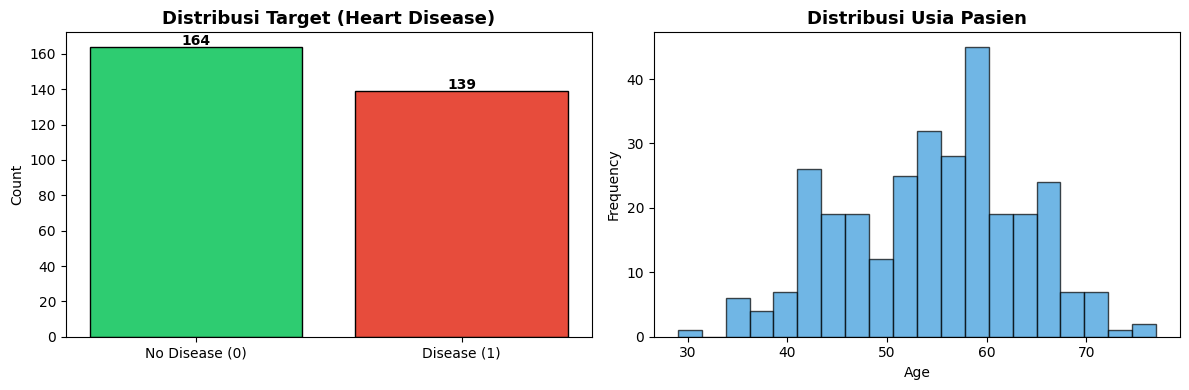

Plot disimpan!


In [7]:
# Distribusi target
df['target_binary'] = (df['target'] > 0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Target distribution
target_counts = df['target_binary'].value_counts()
axes[0].bar(['No Disease (0)', 'Disease (1)'], target_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Distribusi Target (Heart Disease)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Age distribution
axes[1].hist(df['age'], bins=20, color='#3498db', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribusi Usia Pasien', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('eda_target_age.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot disimpan!')

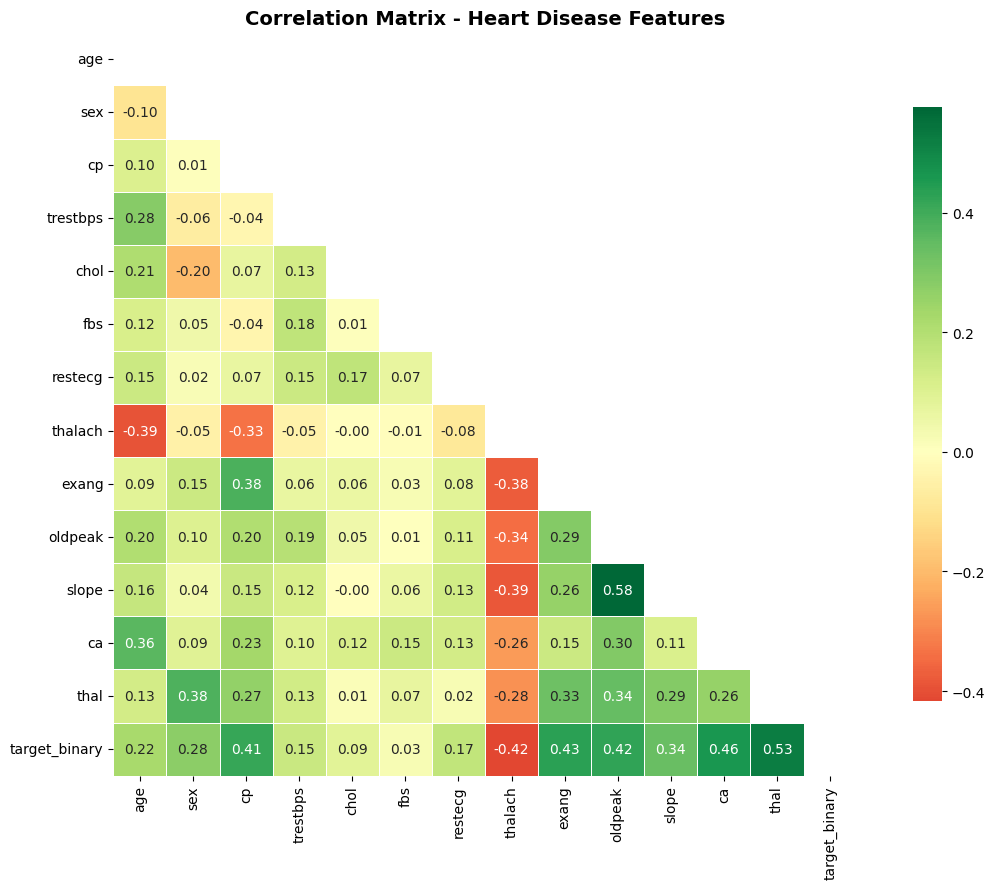

In [8]:
# Correlation heatmap
plt.figure(figsize=(12, 9))
corr_matrix = df.drop('target', axis=1).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix - Heart Disease Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

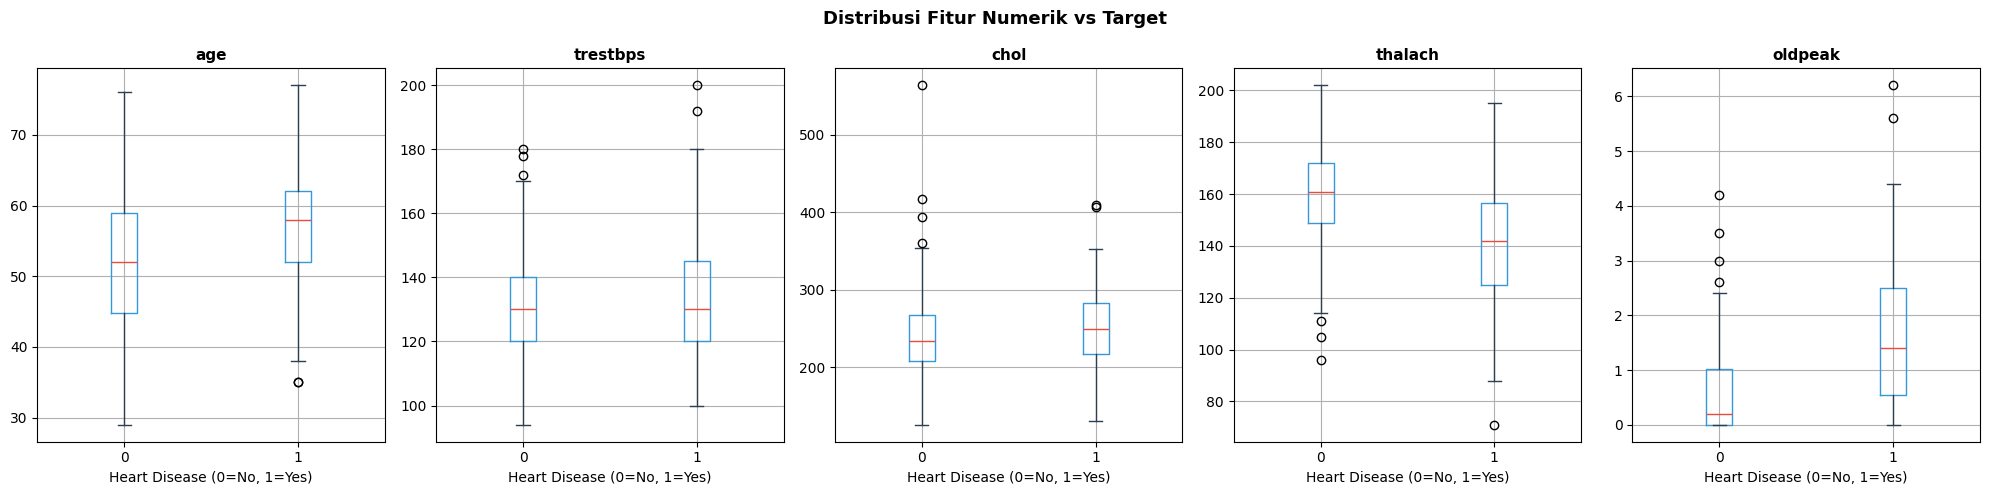

In [9]:
# Boxplot fitur numerik vs target
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, col in enumerate(numerical_cols):
    df.boxplot(column=col, by='target_binary', ax=axes[i],
               color=dict(boxes='#3498db', whiskers='#2c3e50', medians='#e74c3c', caps='#2c3e50'))
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Heart Disease (0=No, 1=Yes)')

plt.suptitle('Distribusi Fitur Numerik vs Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

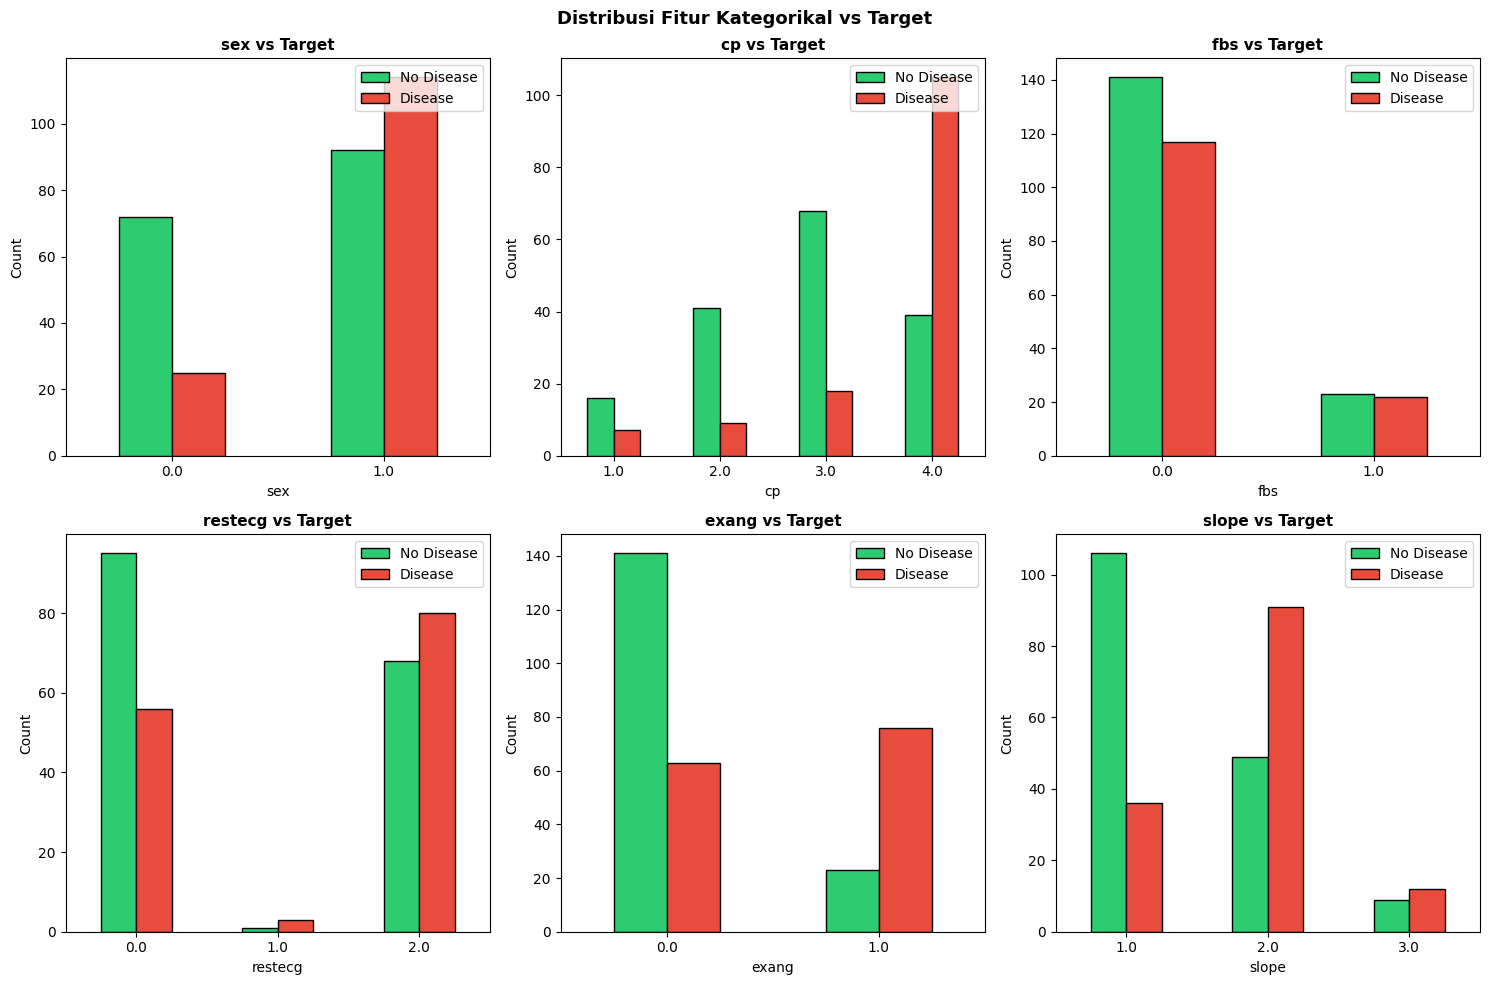

In [10]:
# Analisis fitur kategorikal
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(df[col], df['target_binary'])
    ct.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'],
            edgecolor='black', legend=True)
    axes[i].set_title(f'{col} vs Target', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(['No Disease', 'Disease'], loc='upper right')

plt.suptitle('Distribusi Fitur Kategorikal vs Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Cek outliers menggunakan IQR
print('=== Deteksi Outlier (IQR Method) ===')
outlier_summary = {}
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)][col].count()
    outlier_summary[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                             'Lower Bound': lower, 'Upper Bound': upper,
                             'Outlier Count': outliers}

outlier_df = pd.DataFrame(outlier_summary).T
print(outlier_df)

=== Deteksi Outlier (IQR Method) ===
             Q1     Q3   IQR  Lower Bound  Upper Bound  Outlier Count
age        48.0   61.0  13.0        28.50        80.50            0.0
trestbps  120.0  140.0  20.0        90.00       170.00            9.0
chol      211.0  275.0  64.0       115.00       371.00            5.0
thalach   133.5  166.0  32.5        84.75       214.75            1.0
oldpeak     0.0    1.6   1.6        -2.40         4.00            5.0


# **5. Data Preprocessing**

Pada tahap ini dilakukan preprocessing data yang meliputi:
1. Konversi target ke binary
2. Penanganan missing values
3. Penanganan outlier (IQR capping)
4. Feature engineering
5. Feature scaling
6. Split data train/test

In [12]:
# Step 1: Buat salinan dataframe
df_processed = df.copy()

# Step 2: Konversi target ke binary (0 = no disease, 1 = disease)
df_processed['target'] = (df_processed['target'] > 0).astype(int)
df_processed = df_processed.drop('target_binary', axis=1, errors='ignore')

print('Step 1-2: Target dikonversi ke binary')
print(df_processed['target'].value_counts())

Step 1-2: Target dikonversi ke binary
target
0    164
1    139
Name: count, dtype: int64


In [13]:
# Step 3: Handle missing values
print('=== Before Imputation ===')
print(df_processed.isnull().sum())

# Kolom ca dan thal memiliki missing values
imputer = SimpleImputer(strategy='median')
cols_to_impute = ['ca', 'thal']
df_processed[cols_to_impute] = imputer.fit_transform(df_processed[cols_to_impute])

print('\n=== After Imputation ===')
print(df_processed.isnull().sum())
print('Missing values berhasil di-handle!')

=== Before Imputation ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

=== After Imputation ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
Missing values berhasil di-handle!


In [14]:
# Step 4: Handle outliers menggunakan IQR capping (Winsorization)
def handle_outliers_iqr(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
    return df_clean

numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
df_processed = handle_outliers_iqr(df_processed, numerical_cols)
print('Step 4: Outlier handling selesai (IQR capping/winsorization)')

Step 4: Outlier handling selesai (IQR capping/winsorization)


In [15]:
# Step 5: Feature Engineering
# Konversi thal dan ca menjadi integer (sudah numerik, pastikan tipe data benar)
df_processed['ca'] = df_processed['ca'].astype(int)
df_processed['thal'] = df_processed['thal'].astype(int)

# Feature baru: age group
df_processed['age_group'] = pd.cut(df_processed['age'],
                                    bins=[0, 40, 55, 70, 100],
                                    labels=[0, 1, 2, 3]).astype(int)

print('Step 5: Feature engineering selesai')
print(f'Jumlah fitur sekarang: {df_processed.shape[1] - 1} (tidak termasuk target)')
df_processed.head()

Step 5: Feature engineering selesai
Jumlah fitur sekarang: 14 (tidak termasuk target)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_group
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0,6,0,2
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3,3,1,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2,7,1,2
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0,3,0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0,3,0,1


In [16]:
# Step 6: Feature Scaling (StandardScaler)
X = df_processed.drop('target', axis=1)
y = df_processed['target']

# Split data (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling hanya pada fitur numerik kontinyu
scale_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

print('Step 6: Feature scaling selesai')
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'y_train distribution:\n{y_train.value_counts()}')

Step 6: Feature scaling selesai
X_train shape: (242, 14)
X_test shape:  (61, 14)
y_train distribution:
target
0    131
1    111
Name: count, dtype: int64


In [17]:
import os
# Step 7: Simpan hasil preprocessing
os.makedirs('heart_disease_preprocessing', exist_ok=True)
train_data = X_train.copy()
train_data['target'] = y_train.values

test_data = X_test.copy()
test_data['target'] = y_test.values

train_data.to_csv('heart_disease_preprocessing/train.csv', index=False)
test_data.to_csv('heart_disease_preprocessing/test.csv', index=False)

print('Step 7: Data preprocessing disimpan!')
print('  -> heart_disease_preprocessing/train.csv')
print('  -> heart_disease_preprocessing/test.csv')

Step 7: Data preprocessing disimpan!
  -> heart_disease_preprocessing/train.csv
  -> heart_disease_preprocessing/test.csv


In [18]:
# Verifikasi akhir
print('=== Verifikasi Data Preprocessing ===')
train_check = pd.read_csv('heart_disease_preprocessing/train.csv')
test_check = pd.read_csv('heart_disease_preprocessing/test.csv')

print(f'Train set shape : {train_check.shape}')
print(f'Test set shape  : {test_check.shape}')
print(f'Missing values  : {train_check.isnull().sum().sum()}')
print(f'\nTrain target distribution:')
print(train_check['target'].value_counts())
print('\nPreprocessing selesai!')

=== Verifikasi Data Preprocessing ===
Train set shape : (242, 15)
Test set shape  : (61, 15)
Missing values  : 0

Train target distribution:
target
0    131
1    111
Name: count, dtype: int64

Preprocessing selesai!


In [19]:
# ══════════════════════════════════════════
# AUTO DOWNLOAD HASIL PREPROCESSING
# ══════════════════════════════════════════
from google.colab import files
import zipfile, os

# Zip semua hasil jadi satu file
with zipfile.ZipFile('hasil_preprocessing.zip', 'w') as zf:
    zf.write('heart_disease_raw.csv')
    zf.write('heart_disease_preprocessing/train.csv', 'heart_disease_preprocessing/train.csv')
    zf.write('heart_disease_preprocessing/test.csv',  'heart_disease_preprocessing/test.csv')

print('File yang akan didownload:')
print('  - heart_disease_raw.csv')
print('  - heart_disease_preprocessing/train.csv')
print('  - heart_disease_preprocessing/test.csv')

files.download('hasil_preprocessing.zip')
print('Download dimulai!')

File yang akan didownload:
  - heart_disease_raw.csv
  - heart_disease_preprocessing/train.csv
  - heart_disease_preprocessing/test.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download dimulai!
